In [1]:
import numpy as np
import mediapy 


# headless rendering
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ["PYOPENGL_PLATFORM"] = "egl"

In [ ]:
traj = np.load('/iris/u/riadoshi/teams/robot-collab/fixed_demos_sweep/traj_006.npz', allow_pickle=True)
mediapy.show_video(traj['video_imgs'], fps=30)

In [6]:
traj['ur5_states'][:, -2]

array([0.79910752, 0.79910235, 0.79909751, 0.79909665, 0.79910391,
       0.7990931 , 0.7990941 , 0.79909474, 0.79909637, 0.79909546,
       0.79909522, 0.79910115, 0.79909207, 0.79910313, 0.79911158,
       0.79911128, 0.7991061 , 0.79910794, 0.79910522, 0.79910525,
       0.7991032 , 0.79910329, 0.79910478, 0.7991131 , 0.79912413,
       0.79912222, 0.79911585, 0.79911267, 0.79911655, 0.799113  ,
       0.79910907, 0.79911838, 0.79910988, 0.79911118, 0.799113  ,
       0.79911254, 0.79909882, 0.79910203, 0.79911464, 0.79910986,
       0.79911293, 0.79911268, 0.79910952, 0.79911387, 0.7991023 ,
       0.79910731, 0.79910813, 0.79911043, 0.79911166, 0.79911619,
       0.79910278, 0.79911049, 0.79911147, 0.79911089, 0.79911819,
       0.79910875, 0.79910665, 0.79910467, 0.7991049 , 0.7991081 ,
       0.79910777, 0.79910393, 0.79910181, 0.79912087, 0.79912053,
       0.79913391, 0.79913278, 0.79914529, 0.79914117, 0.79914113,
       0.79913331, 0.7991475 , 0.79913752, 0.79913748, 0.79914

In [7]:
def convert_simaction_to_action(traj_actions):

    default_ur5_gripper = 255.0
    default_panda_gripper = 0.0

    new_actions = []
    for action in traj_actions:
        ctrl_idxs, ctrl_vals = action.ctrl_idxs, action.ctrl_vals
        ctrl_map = {idx:val for (idx, val) in zip(ctrl_idxs, ctrl_vals)}

        ur5_arm = [ctrl_map[i] for i in [1, 2, 3, 4, 5, 6]]  # shoulder_pan to wrist_3
        ur5_gripper = ctrl_map.get(7, default_ur5_gripper)   # index 7
        ur5_base = ctrl_map[0]  

        panda_arm = [ctrl_map[i] for i in [9, 10, 11, 12, 13, 14, 15]]  # joint1 to joint7
        panda_gripper = ctrl_map.get(16, default_panda_gripper)         # index 16
        panda_base = ctrl_map[8]

        action = np.array([
            *ur5_arm,        # 6 elements
            ur5_gripper,     # 1 element
            ur5_base,        # 1 element
            *panda_arm,      # 7 elements
            panda_gripper,   # 1 element
            panda_base       # 1 element
        ])
        
        new_actions.append(action)

    return new_actions


In [ ]:
import sys
sys.path.append('..')
from rocobench.envs.task_sweep import SweepTask
from rocobench.envs.base_env import SimAction


for i in [15, 16, 18]:
    traj = np.load(f'/iris/u/riadoshi/teams/robot-collab/fixed_demos_sweep/traj_0{i:02d}.npz', allow_pickle=True)


    # Initialize the environment
    env = SweepTask(np_seed=i,sim_forward_steps=100,  # This matches the data collection
        render_freq=2000,       # Also used during collection at control_freq=10
        error_freq=3,
        error_threshold=1e-3)
    obs = env.reset()

    new_actions = convert_simaction_to_action(traj['actions'])

    frames = []
    for i,action_vals in enumerate(new_actions):
        new_ctrl_idxs = [1,2,3,4,5,6,7,0,9,10,11,12,13,14,15,16,8]

        sim_action = SimAction(
            ctrl_idxs=new_ctrl_idxs,
            ctrl_vals=action_vals,
            qpos_idxs=[],
            qpos_target=[],
            eq_active_idxs=None,
            eq_active_vals=None,
        )
        obs = env.step(sim_action)

        frame = env.physics.render(camera_id='video', height=480, width=640)
        frames.append(frame)

    # mediapy.show_video(frames, fps=30)

In [4]:
# Check if the contents of ctrl_idxs are the same for all actions in the trajectory
first_ctrl_idxs = np.asarray(traj['actions'][0].ctrl_idxs)
all_equal = True
for i, action in enumerate(traj['actions'][1:], 1):
    if not np.array_equal(action.ctrl_idxs[:15], first_ctrl_idxs[:15]):
        print(f"Step {i}: ctrl_idxs differ from the first step.")
        all_equal = False
        break
print("Are all ctrl_idxs the same across the trajectory?", all_equal)


ctrl_idxes = traj['actions'][0].ctrl_idxs[:17]
# Replay new_actions in sim environment, constructing SimAction at each step using ctrl_idxes and new_actions.


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Are all ctrl_idxs the same across the trajectory? True


In [5]:
ctrl_idxes

array([ 1,  2,  3,  4,  5,  6,  0,  9, 10, 11, 12, 13, 14, 15,  8,  7, 16],
      dtype=int32)

In [ ]:
# Verify the conversion is exact
import sys
sys.path.append('..')
from rocobench.envs.task_sweep import SweepTask

# Initialize the environment
env = SweepTask(np_seed=2)
obs = env.reset()
new_actions = convert_simaction_to_action(traj['actions'])
frames = []



In [ ]:
from rocobench.envs.base_env import SimAction
import time


env = SweepTask(np_seed=5)
obs = env.reset()
new_actions = convert_simaction_to_action(traj['actions'])
replay_video_frames = []

for i,action_vals in enumerate(new_actions):
    new_ctrl_idxs = [1,2,3,4,5,6,7,0,9,10,11,12,13,14,15,16,8]

    sim_action = SimAction(
        ctrl_idxs=new_ctrl_idxs,
        ctrl_vals=action_vals,
        qpos_idxs=[],
        qpos_target=[],
        eq_active_idxs=None,
        eq_active_vals=None,
    )
    obs = env.step(sim_action)

    frame = env.physics.render(camera_id='video', height=480, width=640)
    replay_video_frames.append(frame)

    # Use ctrl_idxes for both ctrl_idxs and set ctrl_vals to action_vals
    # reframed_action = np.array([
    #     *action_vals[0:6],   # positions 0-5: ur5_arm (ctrl_idxs 1-6)
    #     action_vals[7],      # position 6: ur5_base (ctrl_idx 0)
    #     *action_vals[8:15],  # positions 7-13: panda_arm (ctrl_idxs 9-15)
    #     action_vals[16],     # position 14: panda_base (ctrl_idx 8)
    #     action_vals[6],      # position 15: ur5_gripper (ctrl_idx 7)
    #     action_vals[15],     # position 16: panda_gripper (ctrl_idx 16)
    # ])

    # if traj['actions'][i].ctrl_vals.shape[0]==15:
    #     reframed_action = reframed_action[:15]
    #     new_ctrl_idxs = ctrl_idxes[:15]
    # elif traj['actions'][i].ctrl_vals.shape[0]==16:
    #     reframed_action = reframed_action[:16]
    #     new_ctrl_idxs = ctrl_idxes[:16]
    # else:
    #     new_ctrl_idxs = ctrl_idxes
    
    

# Optionally, show the replay video
mediapy.show_video(replay_video_frames, fps=30)



IndentationError: unexpected indent (258415711.py, line 18)

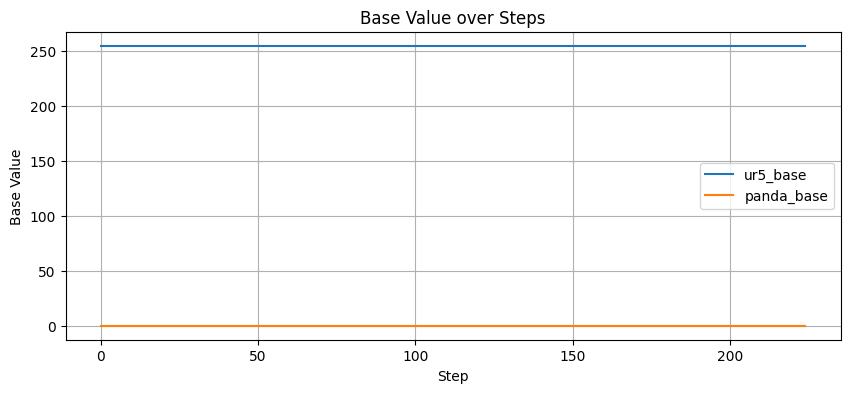

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot([a[6] for a in new_actions], label='ur5_base')
plt.plot([a[15] for a in new_actions], label='panda_base')

plt.xlabel('Step')
plt.ylabel('Base Value')
plt.title('Base Value over Steps')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:



import sys
sys.path.append('..')
from rocobench.envs.task_sweep import SweepTask


# Initialize the environment
env = SweepTask(np_seed=2)
obs = env.reset()

video_frames = []

actions = traj['actions']
steps = len(actions)

for t in range(steps):
    action = actions[t]
    obs = env.step(action)
    frame = env.physics.render(camera_id='video', height=480, width=640)
    video_frames.append(frame)



# Optionally, show the video inline:
mediapy.show_video(video_frames, fps=30)



In [ ]:
# Check the exact seed used for this demo
print(f"Demo file: traj_005.npz")
print(f"Your replay seed: 5")
print("\nChecking if original actions use qpos or eq_active:")

sample_action = traj['actions'][0]
print(f"  qpos_idxs: {sample_action.qpos_idxs}")
print(f"  qpos_target: {sample_action.qpos_target}")
print(f"  eq_active_idxs: {sample_action.eq_active_idxs}")
print(f"  eq_active_vals: {sample_action.eq_active_vals}")

# Check if any action in the trajectory uses these
uses_qpos = any(len(a.qpos_idxs) > 0 for a in traj['actions'])
uses_eq = any(a.eq_active_idxs is not None and len(a.eq_active_idxs) > 0 for a in traj['actions'])
print(f"\nAny action uses qpos: {uses_qpos}")
print(f"Any action uses eq_active: {uses_eq}")


In [ ]:
# Try replaying with the ORIGINAL actions (no conversion)
import sys
sys.path.append('..')
from rocobench.envs.task_sweep import SweepTask
from rocobench.envs.base_env import SimAction

env = SweepTask(
    np_seed=5,
    sim_forward_steps=300,
    render_freq=2000,
    error_freq=30,
    error_threshold=1e-5
)
obs = env.reset()

frames_original = []
for i, action in enumerate(traj['actions']):
    obs = env.step(action)  # Use original action directly!
    frame = env.physics.render(camera_id='video', height=480, width=640)
    frames_original.append(frame)

mediapy.show_video(frames_original, fps=30)


In [ ]:
# Replay with EXACT same params as demo generation (defaults!)
import sys
sys.path.append('..')
from rocobench.envs.task_sweep import SweepTask
from rocobench.envs.base_env import SimAction

env = SweepTask(
    np_seed=5,  # Use defaults for everything else
)
obs = env.reset()

frames_default = []
for i, action in enumerate(traj['actions']):
    obs = env.step(action)
    frame = env.physics.render(camera_id='video', height=480, width=640)
    frames_default.append(frame)

mediapy.show_video(frames_default, fps=30)
